In [1]:
import warnings
warnings.filterwarnings("ignore") #supressing warnings because numpy and M4s result in matmul divide by 0 errors that should not exist

In [2]:
import os, sys
import numpy as np
import pandas as pd

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# stats stuff
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy import stats
from scipy.stats import pearsonr, spearmanr

# pca stuff
from sklearn.decomposition import PCA


In [3]:
ROOT_DIR    = os.path.abspath('..')

In [4]:
parcellation = "aparc"
#parcellation = "HCP.fsaverage.aparc"
#parcellation = "Schaefer_200"

In [5]:
# set minimum number of vertices based on parcellation (manual for now)
match parcellation:
    case "aparc":
        n_minimum = 200
    case "HCP.fsaverage.aparc":
        n_minimum = 100
    case "Schaefer_200":
        n_minimum = 2

In [6]:
#META_PATH   = os.path.join(ROOT_DIR, 'mind-test', 'healthy_eids.csv')
MAIN_DIR = os.path.join(ROOT_DIR, 'mind-test')
DATA_DIR    = os.path.join(ROOT_DIR, 'mind-test', 'test_dataset')
PLOT_DIR = os.path.join(ROOT_DIR, 'mind-test', f'plots_{parcellation}')
os.makedirs(PLOT_DIR, exist_ok=True)

In [7]:
from src.MIND_helpers import calculate_mind_network, calculate_mind_network_fast
from src.convert_to_mgz import convert_to_mgz
from src.get_vertex_df import get_vertex_df
from src.filter_scale_vertex_data import filter_vertex_data, scale_vertex_data
from src import plots

In [8]:
surf_dir = os.path.join(DATA_DIR, "mystery_man", "surfaces", "mystery_man")
features = ["CT", "MC", "Vol", "SD", "SA"]

In [9]:
t1_vertex_data, combined_regions, used_features = get_vertex_df(surf_dir, features, parcellation)

lh
Loading left hemisphere data:
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.thickness
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.curv
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.volume
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.sulc
/Users/skc48/Library/CloudStorage/OneDrive-UniversityofCambridge/Documents/sarah_crockford/mind-test/test_dataset/mystery_man/surfaces/mystery_man/surf/lh.area
['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
0 Feature_0
1 Feature_1
2 Feature_2
3 Feature_3
4 Feature_4
rh
Loading right hemisphere data:


In [14]:
feature_conv_dict = dict(zip(list(features), list(used_features)))
feature_conv_dict

{'CT': 'Feature_0',
 'MC': 'Feature_1',
 'Vol': 'Feature_2',
 'SD': 'Feature_3',
 'SA': 'Feature_4'}

In [15]:
# rename to features
t1_vertex_data_n = t1_vertex_data.rename(columns={'Feature_0': features[0],
                                          'Feature_1': features[1],
                                          'Feature_2': features[2],
                                          'Feature_3': features[3],
                                          'Feature_4': features[4]})

Check features seem to have loaded correctly

In [17]:
print(t1_vertex_data_n.describe())

                  CT             MC            Vol             SD  \
count  237778.000000  237778.000000  237778.000000  237778.000000   
mean        2.795908      -0.039801       2.049291      -0.020719   
std         0.687954       0.179961       1.385437       5.377067   
min         0.000000      -1.285353       0.000000     -13.875164   
25%         2.329075      -0.177313       1.041110      -4.175653   
50%         2.783759      -0.013865       1.735212      -0.449652   
75%         3.255218       0.106555       2.735088       3.782685   
max         5.000000       0.705612      22.216202      17.433445   

                  SA  
count  237778.000000  
mean        0.664698  
std         0.311255  
min         0.014600  
25%         0.425035  
50%         0.660781  
75%         0.875548  
max         4.657040  


In [18]:
filter_vertices = True

columns = ['Label'] + used_features

vertex_data = t1_vertex_data

feature_conv_dict = dict(zip(list(features), list(used_features)))
# The filter_vertices parameter determines you want to filter out all the non-biologically feasible vertices (i.e. any of volume, surface area or cortical thickness equalling zero)
if filter_vertices == True:

    if 'CT' in features:
        vertex_data = vertex_data.drop(vertex_data[vertex_data[feature_conv_dict['CT']] == 0].index)

    if 'Vol' in features:
        vertex_data = vertex_data.drop(vertex_data[vertex_data[feature_conv_dict['Vol']] == 0].index)

    if 'SA' in features:
        vertex_data = vertex_data.drop(vertex_data[vertex_data[feature_conv_dict['SA']] == 0].index)

vertex_data = vertex_data[columns]


In [19]:
print(f"Before filtering: {len(t1_vertex_data)} rows")
print(f"After filtering:  {len(vertex_data)} rows")
print(f"Removed:          {len(t1_vertex_data) - len(vertex_data)} rows")

Before filtering: 237778 rows
After filtering:  237696 rows
Removed:          82 rows


In [20]:
for feat in ('CT', 'Vol', 'SA'):
    if feat in features:
        col = feature_conv_dict[feat]
        n_zeros = (vertex_data[col] == 0).sum()
        print(f"{feat} ({col}): {n_zeros} zeros remaining")

CT (Feature_0): 0 zeros remaining
Vol (Feature_2): 0 zeros remaining
SA (Feature_4): 0 zeros remaining


In [21]:
for feat in ('CT', 'Vol', 'SA'):
    if feat in features:
        col = feature_conv_dict[feat]
        n_zeros_before = (t1_vertex_data[col] == 0).sum()
        print(f"{feat} ({col}): {n_zeros_before} zeros before filtering")

CT (Feature_0): 30 zeros before filtering
Vol (Feature_2): 59 zeros before filtering
SA (Feature_4): 0 zeros before filtering


In [24]:
features2filter = ('CT', 'Vol', 'SA')
columns = ['Label'] + list(used_features)
feature_conv_dict = dict(zip(features, used_features))

vertex_data_clean = t1_vertex_data.copy()

if filter_vertices:
    #for feat in ('CT', 'Vol', 'SA'):
    for feat in features2filter:
        if feat in features:
            col = feature_conv_dict[feat]
            vertex_data_clean = vertex_data_clean[vertex_data_clean[col] != 0]

vertex_data_clean = vertex_data_clean[columns]
n_removed_vertices = len(vertex_data) - len(vertex_data_clean)


In [25]:
print(f"Before filtering: {len(t1_vertex_data)} rows")
print(f"After filtering:  {len(vertex_data_clean)} rows")
print(f"Removed:          {len(t1_vertex_data) - len(vertex_data_clean)} rows")

Before filtering: 237778 rows
After filtering:  237696 rows
Removed:          82 rows


In [26]:
for feat in ('CT', 'Vol', 'SA'):
    if feat in features:
        col = feature_conv_dict[feat]
        n_zeros = (vertex_data_clean[col] == 0).sum()
        print(f"{feat} ({col}): {n_zeros} zeros remaining")

CT (Feature_0): 0 zeros remaining
Vol (Feature_2): 0 zeros remaining
SA (Feature_4): 0 zeros remaining


In [28]:
print("features:      ", list(features))
print("used_features: ", list(used_features))
print("conv_dict:     ", feature_conv_dict)

features:       ['CT', 'MC', 'Vol', 'SD', 'SA']
used_features:  ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
conv_dict:      {'CT': 'Feature_0', 'MC': 'Feature_1', 'Vol': 'Feature_2', 'SD': 'Feature_3', 'SA': 'Feature_4'}


In [29]:
for feat, col in feature_conv_dict.items():
    print(f"{feat} -> {col}: min={t1_vertex_data[col].min():.3f}, max={t1_vertex_data[col].max():.3f}")

CT -> Feature_0: min=0.000, max=5.000
MC -> Feature_1: min=-1.285, max=0.706
Vol -> Feature_2: min=0.000, max=22.216
SD -> Feature_3: min=-13.875, max=17.433
SA -> Feature_4: min=0.015, max=4.657


In [30]:
def filter_vertex_data(vertex_data, features_manual_list, features_generated_list,
                       features2filter=('CT', 'Vol', 'SA'),
                       verbose=False):
    columns = ['Label'] + list(features_generated_list)
    feature_conv_dict = dict(zip(features_manual_list, features_generated_list))

    vertex_data_clean = vertex_data.copy()

    for feat in features2filter:
        if feat in features_manual_list:
            col = feature_conv_dict[feat]
            vertex_data_clean = vertex_data_clean[vertex_data_clean[col] != 0]

    vertex_data_clean = vertex_data_clean[columns]
    n_removed_vertices = len(vertex_data) - len(vertex_data_clean)

    # Per-label counts: before, after, removed, % retained
    counts_before = vertex_data['Label'].value_counts()
    counts_after = vertex_data_clean['Label'].value_counts()

    per_label_stats = pd.DataFrame({
        'n_before': counts_before,
        'n_after': counts_after.reindex(counts_before.index, fill_value=0),
    })
    per_label_stats['n_removed'] = per_label_stats['n_before'] - per_label_stats['n_after']
    per_label_stats['pct_retained'] = 100 * per_label_stats['n_after'] / per_label_stats['n_before']
    per_label_stats = per_label_stats.sort_values('pct_retained')

    if verbose:
        print("VERTEX DATA CLEAN UP LOGGING")
        print("=== Features list being used and final conversion dictionaries ===")
        print("features:      ", list(features_manual_list))
        print("used_features: ", list(features_generated_list))
        print("conv_dict:     ", feature_conv_dict)
        print("=== Inspect orginal data compared to cleaned up data ===")
        print(f"Before filtering: {len(vertex_data)} rows")
        print(f"After filtering:  {len(vertex_data_clean)} rows")
        print(f"Removed:          {len(vertex_data) - len(vertex_data_clean)} rows")
        for feat in features2filter:
            if feat in features_manual_list:
                col = feature_conv_dict[feat]
                n_zeros_before = (vertex_data[col] == 0).sum()
                print(f"{feat} ({col}): {n_zeros_before} zeros before filtering")
        for feat in features2filter:
            if feat in features_manual_list:
                col = feature_conv_dict[feat]
                n_zeros = (vertex_data_clean[col] == 0).sum()
                print(f"{feat} ({col}): {n_zeros} zeros remaining")
        print("=== Check summaries for original data ===")
        for feat, col in feature_conv_dict.items():
            print(f"{feat} -> {col}: min={vertex_data[col].min():.3f}, max={vertex_data[col].max():.3f}")
        print("=== Check summaries for cleaned up data ===")
        for feat, col in feature_conv_dict.items():
            print(f"{feat} -> {col}: min={vertex_data_clean[col].min():.3f}, max={vertex_data_clean[col].max():.3f}")

    return vertex_data_clean, n_removed_vertices, per_label_stats


In [31]:
vt_clean, n_removed, stats = filter_vertex_data(t1_vertex_data, features, used_features,
                                                features2filter=('CT', 'Vol', 'SA'),
                                                verbose=True)

VERTEX DATA CLEAN UP LOGGING
=== Features list being used and final conversion dictionaries ===
features:       ['CT', 'MC', 'Vol', 'SD', 'SA']
used_features:  ['Feature_0', 'Feature_1', 'Feature_2', 'Feature_3', 'Feature_4']
conv_dict:      {'CT': 'Feature_0', 'MC': 'Feature_1', 'Vol': 'Feature_2', 'SD': 'Feature_3', 'SA': 'Feature_4'}
=== Inspect orginal data compared to cleaned up data ===
Before filtering: 237778 rows
After filtering:  237696 rows
Removed:          82 rows
CT (Feature_0): 30 zeros before filtering
Vol (Feature_2): 59 zeros before filtering
SA (Feature_4): 0 zeros before filtering
CT (Feature_0): 0 zeros remaining
Vol (Feature_2): 0 zeros remaining
SA (Feature_4): 0 zeros remaining
=== Check summaries for original data ===
CT -> Feature_0: min=0.000, max=5.000
MC -> Feature_1: min=-1.285, max=0.706
Vol -> Feature_2: min=0.000, max=22.216
SD -> Feature_3: min=-13.875, max=17.433
SA -> Feature_4: min=0.015, max=4.657
=== Check summaries for cleaned up data ===
CT -> F

In [32]:
stats

,n_before,n_after,n_removed,pct_retained
Label,,,,
lh_parahippocampal,965,956,9,99.067358
lh_isthmuscingulate,1364,1353,11,99.193548
rh_insula,3409,3382,27,99.207979
rh_isthmuscingulate,1183,1176,7,99.408284
rh_medialorbitofrontal,2936,2922,14,99.523161
...,...,...,...,...
lh_lingual,3703,3703,0,100.000000
rh_lateralorbitofrontal,3612,3612,0,100.000000
lh_caudalmiddlefrontal,3504,3504,0,100.000000


In [34]:
scaled_vertex = scale_vertex_data(vt_clean)
scaled_vertex

,Label,Feature_0,Feature_1,Feature_2,Feature_3,Feature_4
0,lh_lateraloccipital,-0.169954,-1.947660,-1.324492,-0.862486,-1.952441
1,lh_lateraloccipital,-0.212547,-1.911564,-1.090737,-0.805936,-1.814630
2,lh_lateraloccipital,-0.224078,-1.794215,-1.149165,-0.791471,-1.833143
3,lh_lateraloccipital,-0.286329,-1.981165,-1.342081,-0.881195,-1.882692
4,lh_lateraloccipital,-0.177636,-1.861440,-1.066825,-0.858275,-1.705905
...,...,...,...,...,...,...
237773,rh_lateralorbitofrontal,1.295761,-1.164972,5.287836,-1.155341,1.573933
237774,rh_lateralorbitofrontal,1.245069,-1.213706,-1.320823,-1.287536,-2.060392
237775,rh_lateralorbitofrontal,1.270509,-1.080602,-0.839792,-1.289825,-1.790555
237776,rh_lateralorbitofrontal,1.992252,0.681966,3.262789,-0.349572,3.319986


In [44]:
from scipy.spatial import cKDTree as KDTree
import numpy as np
import pandas as pd
from collections import defaultdict
from joblib import Parallel, delayed

def is_outlier(points, thresh=7): #taken from https://stackoverflow.com/questions/22354094/pythonic-way-of-detecting-outliers-in-one-dimensional-observation-data

    """
    Returns a boolean array with True if points are outliers and False
    otherwise.

    Parameters:
    -----------
        points : An numobservations by numdimensions array of observations
        thresh : The modified z-score to use as a threshold. Observations with
            a modified z-score (based on the median absolute deviation) greater
            than this value will be classified as outliers.

    Returns:
    --------
        mask : A numobservations-length boolean array.

    References:
    ----------
        Boris Iglewicz and David Hoaglin (1993), "Volume 16: How to Detect and
        Handle Outliers", The ASQC Basic References in Quality Control:
        Statistical Techniques, Edward F. Mykytka, Ph.D., Editor.
    """
    if len(points.shape) == 1:
        points = points[:,None]
    median = np.median(points, axis=0)
    diff = np.sum((points - median)**2, axis=-1)
    diff = np.sqrt(diff)
    med_abs_deviation = np.median(diff)

    modified_z_score = 0.6745 * diff / med_abs_deviation

    return modified_z_score > thresh

def get_KDTree(x): #Inspired by https://gist.github.com/atabakd/ed0f7581f8510c8587bc2f41a094b518

    # Check the dimensions are consistent
    x = np.atleast_2d(x)

    # Build a KD tree representation of the samples
    xtree = KDTree(x)

    return xtree

def get_KL(x, y, xtree, ytree): #Inspired by https://gist.github.com/atabakd/ed0f7581f8510c8587bc2f41a094b518


    x = np.atleast_2d(x)
    y = np.atleast_2d(y)

    x = np.atleast_2d(x)
    y = np.atleast_2d(y)

    n,d = x.shape
    m,dy = y.shape

    #Check dimensions
    assert(d == dy)

    # Get the first two nearest neighbours for x, since the closest one is the
    # sample itself.
    r = xtree.query(x, k=2, eps=.01, p=2)[0][:,1]
    s = ytree.query(x, k=1, eps=.01, p=2)[0]

    # SARAH ADD: Suppress warnings - zeros and NaNs are handled below
    # need to suppress for DWI MIND not required for T1
    # DWI voxels are larger so some ROIs have very few data points, leading to degenerate KD-tree distributions where s collapses to zero
    # however, although this issue is already handled, warnings are still being generated
    with np.errstate(divide='ignore', invalid='ignore'):
        rs_ratio = r / s

    #Remove points with zero, nan, or infinity. This happens when two regions have a vertex with the exact same value – an occurence that basically onnly happens for the single feature MSNs
    #and has to do with FreeSurfer occasionally outputting the exact same value for different vertices.
    rs_ratio = rs_ratio[np.isfinite(rs_ratio)]
    rs_ratio = rs_ratio[rs_ratio!=0.0]

    # There is a mistake in the paper. In Eq. 14, the right side misses a negative sign
    # on the first term of the right hand side.

    kl = -np.log(rs_ratio).sum() * d / n + np.log(m / (n - 1.))
    kl = np.maximum(kl, 0)

    return kl

def calculate_mind_network(data_df, feature_cols, region_list):

    MIND = pd.DataFrame(np.zeros((len(region_list), len(region_list))), \
                        index = region_list, columns = region_list)

    grouped_data = data_df.groupby('Label')

    KDtrees = defaultdict(object)

    for i, (name_x, dat_x) in enumerate(grouped_data):
        tree = get_KDTree(dat_x[feature_cols])
        KDtrees[name_x] = tree

    used_pairs = []

    for i, (name_x, dat_x) in enumerate(grouped_data):

        for name_y, dat_y in grouped_data:
            if name_x == name_y:
                continue

            if set([name_x,name_y]) in used_pairs:
                continue

            dat_x = dat_x[feature_cols]
            dat_y = dat_y[feature_cols]

            KLa = get_KL(dat_x, dat_y, KDtrees[name_x], KDtrees[name_y])
            KLb = get_KL(dat_y, dat_x, KDtrees[name_y], KDtrees[name_x])

            kl = KLa + KLb

            MIND.at[name_x,name_y] = 1/(1+kl)
            MIND.at[name_y,name_x] = 1/(1+kl)

            used_pairs.append(set([name_x,name_y]))

    MIND = MIND[region_list].T[region_list].T
    MIND.index = MIND.columns  # reset index to match columns, important if subcortical is excluded

    return MIND

def compute_pair(name_x, name_y, dat_x, dat_y, tree_x, tree_y, feature_cols):
    dx = dat_x[feature_cols]
    dy = dat_y[feature_cols]
    KLa = get_KL(dx, dy, tree_x, tree_y)
    KLb = get_KL(dy, dx, tree_y, tree_x)
    return name_x, name_y, 1 / (1 + KLa + KLb)

def calculate_mind_network_fast(data_df,
                                feature_cols,
                                region_list,
                                percentage_change,  # e.g. per_label_stats["pct_retained"]
                                n_jobs=8,
                                pct_threshold=50.0,
                                min_vertices=1,
                                verbose=False):

    MIND = pd.DataFrame(np.zeros((len(region_list), len(region_list))),
                        index=region_list, columns=region_list)

    # Convert to dict — faster than repeated groupby iteration
    grouped_data = {name: dat for name, dat in data_df.groupby('Label')}

    # Only use regions that are actually in the data
    regions = [r for r in region_list if r in grouped_data]

    if regions == list(region_list):
        print("✓ regions matches region_list exactly (same items, same order)")
    else:
        print("✗ regions differs from region_list")
        print(f"  region_list: {len(region_list)} items")
        print(f"  regions:     {len(regions)} items")
        print(f"  missing:     {sorted(set(region_list) - set(regions))}")
        print(f"  extra:       {sorted(set(regions) - set(region_list))}")

    # Identify regions that didn't retain enough vertices.
    # A region is "undersized" if it's missing from percentage_change
    # (never appeared / lost all vertices) OR fell below the threshold.
    # percentages and threshold set as input to the function, where minium % is 50 and minimum vertex count is 1
    # THESE ARE NOT SCIENTIFICALLY SOUND
    # But, i.e., setting vertex count minimum to 1 stops the MIND computation from crashing out if a whole ROI is empty
    # SO treat the presets as 'crash out' fail safes and NOT scientific parameters

    sizes = {name: len(dat) for name, dat in grouped_data.items()}
    undersized = {
        r for r in regions
        if r not in percentage_change.index
        or percentage_change.loc[r] < pct_threshold
        or sizes[r] < min_vertices
    }

    if undersized:
        if verbose:
            print(f"Found {len(undersized)} regions with < {pct_threshold}% vertex retention "
                  f"(will return NaN for their pairs):")
            print(f"undersized set has {len(undersized)} items: {sorted(undersized)}")
            print(f"percentage_change index has {len(percentage_change.index)} entries, "
                  f"{percentage_change.index.duplicated().sum()} duplicates")
        for r in sorted(undersized):
            pct = percentage_change.loc[r] if r in percentage_change.index else float('nan')
            n = len(grouped_data[r])
            if verbose:
                print(f"  {r}: n={n}, pct_retained={pct:.1f}%")

    # Build KD-trees only for regions that meet the minimum
    KDtrees = {name: get_KDTree(dat[feature_cols])
               for name, dat in grouped_data.items()
               if name not in undersized}

    # Generate all unique pairs upfront
    all_pairs = [(regions[i], regions[j])
                 for i in range(len(regions))
                 for j in range(i + 1, len(regions))]

    # Split into pairs to compute vs pairs to set as NaN
    pairs_to_compute = [(a, b) for a, b in all_pairs
                        if a not in undersized and b not in undersized]
    pairs_to_skip = [(a, b) for a, b in all_pairs
                     if a in undersized or b in undersized]

    print(f"Computing {len(pairs_to_compute)} region pairs across {n_jobs} cores "
          f"(skipping {len(pairs_to_skip)} pairs involving undersized regions)...")

    # Parallelise across valid pairs only
    results = Parallel(n_jobs=n_jobs, backend="loky")(#, verbose=10)(
        delayed(compute_pair)(
            name_x, name_y,
            grouped_data[name_x], grouped_data[name_y],
            KDtrees[name_x], KDtrees[name_y],
            feature_cols
        )
        for name_x, name_y in pairs_to_compute
    )

    # Fill matrix with computed values
    for name_x, name_y, val in results:
        MIND.at[name_x, name_y] = val
        MIND.at[name_y, name_x] = val

    # Fill NaN for pairs involving undersized regions
    for name_x, name_y in pairs_to_skip:
        MIND.at[name_x, name_y] = np.nan
        MIND.at[name_y, name_x] = np.nan

    # Also set diagonal of undersized regions to NaN
    for r in undersized:
        MIND.at[r, r] = np.nan

    MIND.index = MIND.columns
    return MIND

In [49]:
MIND_tst = calculate_mind_network_fast(scaled_vertex,
                                       used_features,
                                       combined_regions,
                                       stats["pct_retained"],
                                       pct_threshold=95,
                                       min_vertices=1,
                                       verbose=True)

✓ regions matches region_list exactly (same items, same order)
Computing 2278 region pairs across 8 cores (skipping 0 pairs involving undersized regions)...


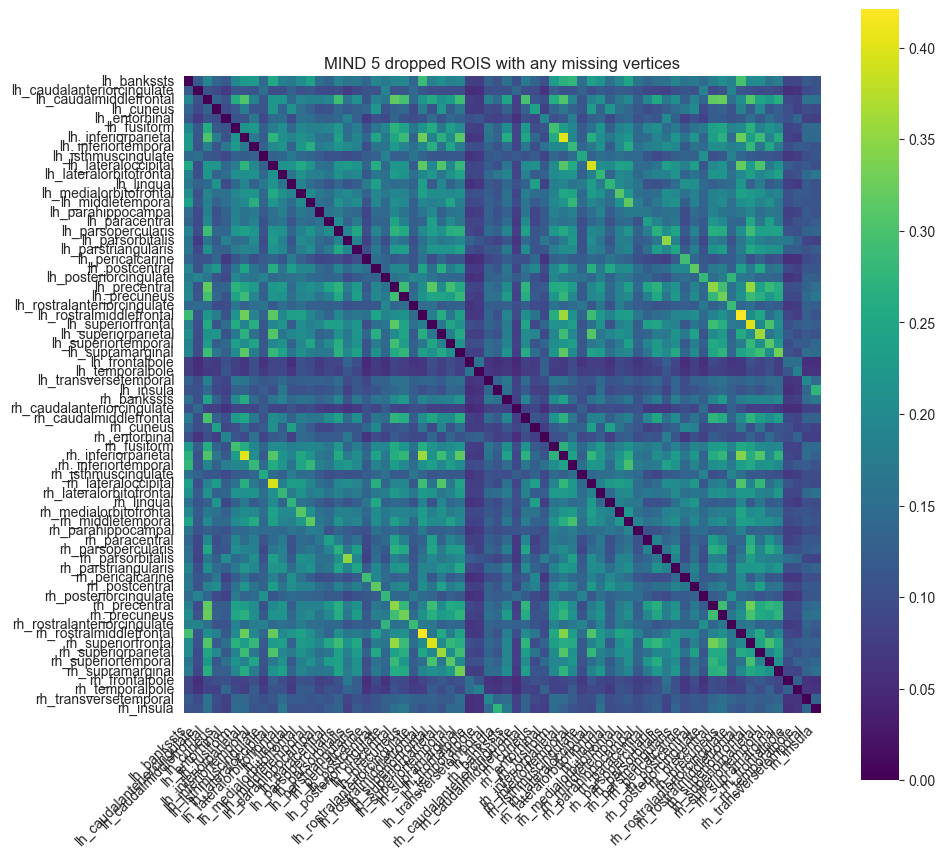

In [50]:
plt.figure(figsize=(10, 9))
labels = combined_regions  # or whatever your row labels are
sns.heatmap(MIND_tst, xticklabels=labels, yticklabels=labels, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('MIND 5 dropped ROIS with any missing vertices')
plt.tight_layout()
plt.show()

DWI DATA

In [ ]:
# Path to FreeSurfer subject directory (needed for parcellation .annot files)
path_to_surf_dir = surf_dir

# Path to the vol2surf_DWI surface outputs for this subject
vol2surf_dir = os.path.join(DATA_DIR, "mystery_man", "surfaces", "vol2surf_DWI", "surface")
tmp_dir = os.path.join(MAIN_DIR, 'tmp_mgz', 'mystery_man')

# DWI metrics available in vol2surf_DWI/surface/
features = {
    'FA':    'dti_FA_T1space_al2std60_back2sub',
    'MD':    'dti_MD_T1space_al2std60_back2sub',
    'ICVF':  'NODDI_ICVF_T1space_al2std60_back2sub',
    'ISOVF': 'NODDI_ISOVF_T1space_al2std60_back2sub',
    'OD':    'NODDI_OD_T1space_al2std60_back2sub',
}

feature_tuples = convert_to_mgz(tmp_dir,
                                vol2surf_dir,
                                path_to_surf_dir,
                                parcellation,
                                features)


In [ ]:
dti_vertex_data, dti_combined_regions, dti_used_features = get_vertex_df(path_to_surf_dir, feature_tuples, parcellation)

In [ ]:
dti_vertex_data_n = dti_vertex_data.rename(columns={'Feature_0': "FA",
                                          'Feature_1': "MD",
                                          'Feature_2': "NDI",
                                          'Feature_3': "ISOVF",
                                          'Feature_4': "OD"})

In [ ]:
# Assuming row order matches within each id
vertex_data_n = pd.concat([t1_vertex_data_n.reset_index(drop=True),
                    dti_vertex_data_n.drop(columns='Label').reset_index(drop=True)],
                   axis=1)

In [ ]:
features_final = list(vertex_data_n.columns[1:])

In [ ]:
# keep only 'good regions' (i.e. drop lh_??
# note that this is a step already performed when computing MIND networks, however for the purposes of all the sanity checking in the notebook
# we will add it in here
vertex_data_n = vertex_data_n[vertex_data_n['Label'].isin(combined_regions)].reset_index(drop=True)

## Clean up and scale data

Sanity check whether ISOVF should be filtered out. If ROIs with ISOVF == 0 are full for other regions unlikely.

NB. I orginally filtered by ISOVF, along with the rest of the metrics listed below and noticed that while FA,MD,NDI and OD were all 0 vertex values for two ROIs (left and right, H + STSva), ISOVF gave 0 values across 65 regions.

This raised my suspicions and based on ISOVF measuring free water volume, it may be possible that true values are indeed 0 (or intrpreted as such from freesurfer).

In [ ]:
# Vertices where ISOVF is 0 but other metrics aren't
isovf_zero = vertex_data_n['ISOVF'] == 0
other_valid = (vertex_data_n[['FA', 'MD', 'NDI', 'OD']] != 0).all(axis=1)

real_low_isovf = isovf_zero & other_valid
missing_data_isovf = isovf_zero & ~other_valid

print(f"ISOVF zeros that are potential low values and not bad data: {real_low_isovf.sum()}")
print(f"ISOVF zeros that are missing/bad data: {missing_data_isovf.sum()}")

# Breakdown by region
real_low_by_region = vertex_data_n.loc[real_low_isovf, 'Label'].value_counts()
missing_by_region = vertex_data_n.loc[missing_data_isovf, 'Label'].value_counts()

print(f"\n--- ISOVF zeros = low values, by ROI ({len(real_low_by_region)} regions) ---")
print(real_low_by_region)

print(f"\n--- ISOVF zeros = missing/bad data, by ROI ({len(missing_by_region)} regions) ---")
print(missing_by_region)

In [ ]:
# RUN QC
vertex_data_clean, n_removed_vertices = filter_vertex_data(vertex_data_n, features_final, features_final, vertices2filter = ('CT', 'Vol', 'SA', 'FA', 'MD', 'NDI', 'OD'))
print(f"Cleaned data and removed {n_removed_vertices} vertices.")

In [ ]:
# scale non clean data
vertex_data_z = scale_vertex_data(vertex_data_n)

# scale clean data
vertex_data_clean_z = scale_vertex_data(vertex_data_clean)

In [ ]:
print(vertex_data_z.shape)
print(vertex_data_z.dtypes)
print(vertex_data_z.index)
print(f"memory: {vertex_data_z.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print(vertex_data_z.head(2))

In [ ]:
mind = calculate_mind_network_fast(vertex_data_z,
                                   features_final,
                                   combined_regions,
                                   n_jobs = 6,
                                   n_minimum = n_minimum)

Check of ROIs with no or small n vertices post data cleaning

In [ ]:
mind_clean = calculate_mind_network_fast(vertex_data_clean_z,
                                         features_final,
                                         combined_regions,
                                         n_jobs = 6,
                                         n_minimum = n_minimum)

In [ ]:
plt.figure(figsize=(10, 9))
labels = combined_regions  # or whatever your row labels are
sns.heatmap(mind, xticklabels=labels, yticklabels=labels, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('MIND 10 RAW')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, f"{parcellation}_mind_10_RAW.png"))
plt.show()

In [ ]:
plt.figure(figsize=(10, 9))
labels = combined_regions

# Use a copy of viridis with NaN cells shown in grey
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='lightgrey')

sns.heatmap(
    mind_clean,
    xticklabels=labels,
    yticklabels=labels,
    cmap=cmap,
    square=True,
    mask=mind.isna(),       # tells seaborn to skip NaN cells
    cbar_kws={'label': 'MIND'},
)

# Optional: grey out the row/column labels for undersized regions
ax = plt.gca()
all_nan_rows = mind_clean.isna().all(axis=1)
for tick, region in zip(ax.get_yticklabels(), labels):
    if all_nan_rows.get(region, False):
        tick.set_color('lightgrey')
for tick, region in zip(ax.get_xticklabels(), labels):
    if all_nan_rows.get(region, False):
        tick.set_color('lightgrey')

plt.xticks(rotation=45, ha='right')
plt.title('MIND clean 10 RAW')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, f"{parcellation}_mind_clean_10_RAW.png"))
plt.show()

In [ ]:
labels = combined_regions
# reconstruct full difference matrix
# negative values mean that the PCA mind resulted in higher (stronger) edge-wise connections
diff_matrix = mind_clean.values - mind.values  # signed differences, NaNs preserved

# Symmetric color limits centered on zero so the diverging cmap is meaningful
vmax = np.nanpercentile(np.abs(diff_matrix), 99)
vmin = -vmax

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    diff_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=vmin,
    vmax=vmax,
    square=True,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"label": "clean − raw"},
    ax=ax,
)
ax.set_title(f"Edge-wise differences (clean − raw) — {parcellation}")
plt.tight_layout()

# Save and show
diff_path = os.path.join(PLOT_DIR, f"{parcellation}_mindclean2raw_diff_heatmap.png")
plt.savefig(diff_path, dpi=200, bbox_inches="tight")
plt.show()
#print(f"Saved heatmap to {diff_path}")

Check agreement between cleaned up and raw MIND networks

In [ ]:
# --- Configure which features to check for zeros ---
zero_check_features = ['CT', 'Vol', 'SA']  + ['FA', 'MD', 'NDI', 'ODI']

# --- Per-feature zero diagnostics ---
zero_stats = {}
for feat in zero_check_features:
    if feat not in vertex_data_n.columns:
        continue
    mask = vertex_data_n[feat] == 0
    by_region = vertex_data_n[mask]['Label'].value_counts()
    zero_stats[feat] = {
        'total': int(mask.sum()),
        'n_regions': int((by_region > 0).sum()),
        'top': by_region.head(20),
    }

# --- Region-size diagnostics (reused for raw and clean) ---
def region_diagnostics(df, combined_regions, min_n=n_minimum, head_n=100):
    sizes = df.groupby('Label').size()
    return {
        'head': sizes.sort_values().head(head_n),
        'missing': set(combined_regions) - set(sizes.index),
        'below_min': sizes[sizes < min_n].to_dict(),
    }

raw_diag = region_diagnostics(vertex_data_z, combined_regions)
clean_diag = region_diagnostics(vertex_data_clean_z, combined_regions)

# --- Edge-level comparison (upper triangle, exclude diagonal) ---
iu = np.triu_indices_from(mind_clean.values, k=1)
raw_edges = mind.values[iu]
nan_edges = mind_clean.values[iu]
valid = ~np.isnan(nan_edges)

r, p = pearsonr(raw_edges[valid], nan_edges[valid])
rho, _ = spearmanr(raw_edges[valid], nan_edges[valid])
diff = raw_edges[valid] - nan_edges[valid]

# --- Build output string ---
lines = ["NB: Nuisance regions (e.g. lh_???) are removed during MIND computation (NOT PRESENT IN FINAL ANALYSIS!).", ""]

lines.append("=== Zero-value vertex counts ===")
for feat, stats_ in zero_stats.items():
    lines.append(f"\n[{feat}] total zero vertices: {stats_['total']}, spread across {stats_['n_regions']} regions")
    lines.append(str(stats_['top']))

lines.append("\n=== Raw MIND region sizes ===")
lines.append(f"First 100 ROIs (smallest first):\n{raw_diag['head']}")
lines.append(f"\nRegions missing from raw MIND: {raw_diag['missing']}")
lines.append(f"Regions in raw MIND with <{n_minimum} vertices: {raw_diag['below_min']}")

lines.append("\n=== Clean MIND region sizes ===")
lines.append(f"First 100 ROIs (smallest first):\n{clean_diag['head']}")
lines.append(f"\nRegions missing from clean MIND: {clean_diag['missing']}")
lines.append(f"Regions in clean MIND with <{n_minimum} vertices: {clean_diag['below_min']}")

lines.append("\n=== Edge-level comparison (raw vs clean) ===")
lines.append(f"Comparing {valid.sum()} of {len(nan_edges)} edges ({100*valid.mean():.1f}%)")
lines.append(f"Pearson r  = {r:.4f}, p = {p:.2e}")
lines.append(f"Spearman ρ = {rho:.4f}")
lines.append(f"Mean difference: {diff.mean():.4f}")
lines.append(f"95% limits: [{diff.mean() - 1.96*diff.std():.4f}, {diff.mean() + 1.96*diff.std():.4f}]")

output = "\n".join(lines)

# Print + save
print(output)

out_path = os.path.join(PLOT_DIR, f"{parcellation}_mind_comparison_stats.txt")
with open(out_path, "w") as f:
    f.write(output + "\n")

#print(f"\nSaved to {out_path}")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(diff[~np.isnan(diff)], bins=60, color="steelblue", edgecolor="white")
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_xlabel("clean − raw")
ax.set_ylabel("Edge count")
ax.set_title(f"Distribution of edge-wise differences between clean MIND and raw MIND")
plt.tight_layout()
diff_hist_path = os.path.join(PLOT_DIR, f"{parcellation}_differences_clean2raw__distribution.png")
plt.savefig(diff_hist_path, dpi=200, bbox_inches="tight")
plt.show()

In [ ]:
features = vertex_data_clean.iloc[:, 1:]
cols = features.columns
n = len(cols)

print(features.describe().loc[['min', 'max', 'mean', 'std']].round(4))

fig, axes = plt.subplots(n, 2, figsize=(11, 3 * n))

for i, col in enumerate(cols):
    data = features[col].dropna()

    # --- Histogram ---
    ax_hist = axes[i, 0]
    ax_hist.hist(data, bins=50, density=True, alpha=0.6, edgecolor='black')

    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 200)
    ax_hist.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2,
                 label=f'N(μ={mu:.2f}, σ={sigma:.2f})')

    # Mark the actual minimum so you can confirm it's > 0
    ax_hist.axvline(data.min(), color='green', linestyle='--', lw=1,
                    label=f'min={data.min():.3f}')

    # Tight x-axis around the actual data range
    pad = (data.max() - data.min()) * 0.02
    ax_hist.set_xlim(data.min() - pad, data.max() + pad)

    ax_hist.set_title(f'{col} — histogram (n={len(data)})')
    ax_hist.set_ylabel('density')
    ax_hist.legend(fontsize=8, loc='upper right')

    # --- Q-Q plot ---
    ax_qq = axes[i, 1]
    stats.probplot(data, dist="norm", plot=ax_qq)
    ax_qq.set_title(f'{col} — Q-Q plot')

plt.tight_layout()
fig.savefig(os.path.join(PLOT_DIR, f'{parcellation}_features_normality.png'),
            dpi=120, bbox_inches='tight')
plt.show()

In [ ]:
final_roi_list = np.array(vertex_data_n.iloc[:,0]) # list of ROIs
id_col   = vertex_data_n.columns[0] # name of the ROI column (Label)
features = vertex_data_n.columns[1:] # final set of features used

In [ ]:
roi_counts = vertex_data_n.groupby('Label').size()
print(roi_counts)

## PCA By ROI

In [ ]:
# minimum number of verteces which should be in a given ROI (default should be 100, as in the calculate_mind_network_fast computation)
#n_minimum = 100

sizes = vertex_data_clean.groupby(id_col).size()
valid_ids = sizes[sizes >= n_minimum].index

df_z = vertex_data_clean[vertex_data_clean[id_col].isin(valid_ids)].copy()
df_z[features] = df_z.groupby(id_col)[features].transform(
    lambda x: (x - x.mean()) / x.std(ddof=1)
)

cov_by_id = df_z.groupby(id_col).cov()

In [ ]:
sizes = df_z.groupby(id_col).size()
print("Groups with n=1:", sizes[sizes == 1])

In [ ]:
print(f"Shape: {df_z.shape}")
print(f"Total NaNs: {df_z.isna().sum().sum()}")
print(f"Total infs: {np.isinf(df_z.select_dtypes(include=np.number)).sum().sum()}")
print(df_z.describe())

In [ ]:
# Where are the NaNs in df_z?
nan_rows = df_z[df_z[features_final].isna().any(axis=1)]
print(f"Rows with NaN: {len(nan_rows)}")
print(f"Unique ids in NaN rows: {nan_rows[id_col].nunique()}")
print("\nGroup sizes for ids with NaNs:")
print(vertex_data_n[vertex_data_n[id_col].isin(nan_rows[id_col])]
      .groupby(id_col).size().value_counts())

In [ ]:
fig, axes = plots.plot_covariance_grid(
    cov_by_id,
    roi_counts,
    ncols=8,
    symmetric=True,  # since your data is z-scored
    save_path=os.path.join(PLOT_DIR, 'covariance.png'),
)
plt.show()

In [ ]:
ids      = cov_by_id.index.get_level_values(0).unique()
features = cov_by_id.columns.tolist()    # length 5

# Stack into a (n_ids, 5, 5) array
stack = np.stack([cov_by_id.loc[i].values for i in ids])

In [ ]:
mean_cov = stack.mean(axis=0)            # average covariance matrix
std_cov  = stack.std(axis=0)             # spread across ROIs

# One-sample t-statistic: how reliably non-zero is each feature-pair
# covariance across ROIs? Treats each ROI as an independent observation
# of the feature x feature relationship.
# (high |mean| relative to std -> consistent across ROIs)
# formula -> mean across ROIs / (std across ROIs / sqrt(n_ROIs))
#         -> mean / SEM
# Large values indicate the feature-pair relationship generalizes across ROIs;
# small values indicate it varies in sign or magnitude from ROI to ROI.

consistency = mean_cov / (std_cov / np.sqrt(len(ids)))
sign_frac = (np.sign(stack) > 0).mean(axis=0)   # fraction of ROIs where pair > 0

In [ ]:
rows = []
for i in range(len(features)):
    for j in range(i + 1, len(features)):     # upper triangle only
        rows.append({
            'feat_a':       features[i],
            'feat_b':       features[j],
            'mean':         mean_cov[i, j],
            'std':          std_cov[i, j],
            'consistency':  consistency[i, j],
            'sign_frac':    sign_frac[i, j],
        })

summary = (pd.DataFrame(rows)
             .assign(abs_consistency=lambda d: d['consistency'].abs())
             .sort_values('sign_frac', ascending=False)
             .drop(columns='abs_consistency'))
# save out
out_path = os.path.join(PLOT_DIR, f"{parcellation}_feature_covariance_summary.txt")
summary.to_csv(out_path, sep="\t", index=False, float_format="%.4f")
#print(f"Saved summary to {out_path}")

print(summary)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, M, title in zip(axes,
                        [mean_cov, consistency],
                        ['Mean covariance', 'Consistency (mean / SE)']):
    M_offdiag = M.copy().astype(float)
    np.fill_diagonal(M_offdiag, np.nan)
    vmax = np.nanmax(np.abs(M_offdiag))
    im = ax.imshow(M, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(len(features))); ax.set_xticklabels(features, rotation=45, ha='right')
    ax.set_yticks(range(len(features))); ax.set_yticklabels(features)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, shrink=0.7)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,"mean_covariance.png"))
plt.show()

In [ ]:
ids      = cov_by_id.index.get_level_values(0).unique()
features = cov_by_id.columns.tolist()
n_feat   = len(features)

eig_by_id = {}
for ident in ids:
    C = cov_by_id.loc[ident].values            # (n_feat, n_feat), symmetric

    # eigh is for symmetric matrices — faster and more stable than eig,
    # and guarantees real eigenvalues. Returns them in ASCENDING order.
    eigvals, eigvecs = np.linalg.eigh(C)

    # Reverse so PC1 is first
    eigvals = eigvals[::-1]
    eigvecs = eigvecs[:, ::-1]

    eig_by_id[ident] = {
        'components': eigvecs.T,                       # (n_components, n_feat)
        'var_exp':    eigvals / eigvals.sum(),         # explained variance ratio
        'eigvals':    eigvals,
    }

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
for ident in ids:
    ax.plot(np.arange(1, n_feat + 1), eig_by_id[ident]['var_exp'],
            color='gray', alpha=0.3, lw=1)

# Overlay the mean
mean_var = np.mean([eig_by_id[i]['var_exp'] for i in ids], axis=0)
ax.plot(np.arange(1, n_feat + 1), mean_var, 'k-', lw=2, label='mean')

ax.set_xlabel('PC'); ax.set_ylabel('Variance explained')
ax.set_xticks(np.arange(1, n_feat + 1))
ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(PLOT_DIR,"scree_plot_all_rois.png")); plt.show()

In [ ]:
def align_sign(v):
    """Flip eigenvector so its largest-magnitude entry is positive."""
    return v if v[np.argmax(np.abs(v))] >= 0 else -v

N_PCS   = 10
ids_arr = np.array(ids)

# --- Collect sign-aligned loadings for all PCs: shape (N_PCS, n_subjects, n_feat)
loadings = np.stack([
    np.stack([align_sign(eig_by_id[i]['components'][k]) for i in ids])
    #np.stack([eig_by_id[i]['components'][k] for i in ids]) # not flipped
    for k in range(N_PCS)
])

# --- Shared subject ordering: cluster on concatenated loadings across all PCs
# so row i is the same subject in every panel.
concat   = loadings.transpose(1, 0, 2).reshape(len(ids), -1)   # (n_subjects, N_PCS * n_feat)
order    = leaves_list(linkage(concat, method='ward'))

# --- Mean variance explained per PC, for the titles
mean_var = np.mean(np.stack([eig_by_id[i]['var_exp'] for i in ids]), axis=0)

# --- Plot
fig, axes = plt.subplots(1, N_PCS, figsize=(3 * N_PCS, 10), sharey=True)

for k, ax in enumerate(axes):
    im = ax.imshow(loadings[k][order], cmap='RdBu_r',
                   vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n_feat))
    ax.set_xticklabels(features, rotation=45, ha='right')
    ax.set_title(f'PC{k + 1}  ({mean_var[k]:.0%} var)')

    if k == 0:
        ax.set_yticks(range(len(ids)))
        ax.set_yticklabels(ids_arr[order], fontsize=6)
    else:
        ax.set_yticks([])

fig.colorbar(im, ax=axes, shrink=0.5, label='loading', pad=0.02)
plt.savefig(os.path.join(PLOT_DIR,"unaligned_roi_by_pc.png"))
plt.show()

In [ ]:
print(type(loadings), loadings.shape if hasattr(loadings, 'shape') else len(loadings))
loadings[0,:,:].shape

In [ ]:
# sort the loadings
X = np.sort(loadings[0,:,:], axis=1)
sq = np.sum(X**2, axis=1)
D_PC1 = np.sqrt(np.maximum(sq[:, None] + sq[None, :] - 2 * X @ X.T, 0))
plt.figure(figsize=(10, 9))
labels = ids_arr  # or whatever your row labels are
sns.heatmap(D_PC1, xticklabels=labels, yticklabels=labels, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('Pairwise distance matrix')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,"PC1_distance_matrix.png"))
plt.show()

In [ ]:
X = np.sort(loadings[1,:,:], axis=1)
sq = np.sum(X**2, axis=1)
D_PC2 = np.sqrt(np.maximum(sq[:, None] + sq[None, :] - 2 * X @ X.T, 0))
plt.figure(figsize=(10, 9))
labels = ids_arr  # or whatever your row labels are
sns.heatmap(D_PC2, xticklabels=labels, yticklabels=labels, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('Pairwise distance matrix')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,"PC2_distance_matrix.png"))
plt.show()

In [ ]:
X = np.sort(loadings[2,:,:], axis=1)
sq = np.sum(X**2, axis=1)
D_PC3 = np.sqrt(np.maximum(sq[:, None] + sq[None, :] - 2 * X @ X.T, 0))
plt.figure(figsize=(10, 9))
labels = ids_arr  # or whatever your row labels are
sns.heatmap(D_PC3, xticklabels=labels, yticklabels=labels, cmap='viridis', square=True)
plt.xticks(rotation=45, ha='right')
plt.title('Pairwise distance matrix')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR,"PC2_distance_matrix.png"))
plt.show()

In [ ]:
for pc in range(N_PCS):
    # Stack everyone's PC1 (using your current align_sign-based loadings)
    pc1 = np.stack([eig_by_id[i]['components'][pc] for i in ids])

    # Reference: mean PC1 across subjects
    ref = pc1.mean(axis=0)
    ref = ref / np.linalg.norm(ref)   # normalize, for clean cosines

    # Cosine similarity of each subject's PC1 with the reference
    cos = pc1 @ ref / np.linalg.norm(pc1, axis=1)

    # Histogram of these tells you which case you're in
    import matplotlib.pyplot as plt
    plt.hist(cos, bins=30)
    plt.xlabel(f'cosine(ROI PC{pc+1}, mean PC{pc+1})'); plt.ylabel('count')
    plt.axvline(0, color='k', lw=0.5)
    plt.savefig(os.path.join(PLOT_DIR,f"cosine_by_pc{pc+1}.png"))
    plt.show()

In [ ]:
# ---------------------------------------------------------------
# Inputs assumed in scope:
#   df          : long-format dataframe, col 0 is id, rest are features
#   id_col      : df.columns[0]
#   features    : df.columns[1:]
#   ids         : array of unique subject IDs (order matches eig_by_id)
#   eig_by_id   : dict from earlier, keyed by id, with 'eigvals'
# ---------------------------------------------------------------

N_SIMS    = 5000      # bootstrap iterations per subject
PCTILE    = 99        # significance threshold (one-sided)
rng       = np.random.default_rng(42)

# Per-subject sample sizes
n_by_id = vertex_data_n.groupby(id_col).size().to_dict()
p       = len(features)

# ---------------------------------------------------------------
# 1. Run parametric bootstrap once per unique sample size
#    (subjects with the same N share the same null distribution)
# ---------------------------------------------------------------
def null_eigenvalues(N, p, n_sims, rng):
    """Eigenvalues of correlation matrices of N×p Gaussian noise, descending."""
    eigs = np.empty((n_sims, p))
    for i in range(n_sims):
        X = rng.standard_normal((N, p))
        C = np.corrcoef(X, rowvar=False)
        eigs[i] = np.sort(np.linalg.eigvalsh(C))[::-1]
    return eigs

unique_Ns = sorted(set(n_by_id.values()))
null_by_N = {N: null_eigenvalues(N, p, N_SIMS, rng) for N in unique_Ns}

# Thresholds per N: the PCTILE percentile of each eigenvalue rank
# (rank 0 = largest noise eigenvalue, etc.)
thresholds_by_N = {N: np.percentile(null_by_N[N], PCTILE, axis=0)
                   for N in unique_Ns}

# ---------------------------------------------------------------
# 2. Per-subject signal/noise table
# ---------------------------------------------------------------
rows = []
for ident in ids:
    N             = n_by_id[ident]
    eigvals       = np.sort(eig_by_id[ident]['eigvals'])[::-1]
    thr           = thresholds_by_N[N]
    is_signal     = eigvals > thr
    n_signal_pcs  = int(is_signal.sum())
    rows.append({
        'id':             ident,
        'N':              N,
        **{f'eig{k+1}':  eigvals[k] for k in range(p)},
        **{f'thr{k+1}':  thr[k]      for k in range(p)},
        **{f'sig{k+1}':  bool(is_signal[k]) for k in range(p)},
        'n_signal_pcs':   n_signal_pcs,
    })
diag = pd.DataFrame(rows).set_index('id')

# Population-level summary
print('Fraction of ROI where each PC clears the noise floor:')
fracs = []
for k in range(p):
    frac = diag[f'sig{k+1}'].mean()
    fracs.append(frac)
    print(f'  PC{k+1}: {frac:.0%}')

# ---------------------------------------------------------------
# 3. Visualization: eigenvalues vs noise floor, per PC rank
# ---------------------------------------------------------------
fig, axes = plt.subplots(1, p, figsize=(3.2 * p, 4.5), sharey=False)

for k, ax in enumerate(axes):
    # Scatter each subject's k-th eigenvalue against their sample size
    Ns        = diag['N'].values
    vals      = diag[f'eig{k+1}'].values
    is_sig    = diag[f'sig{k+1}'].values
    ax.scatter(Ns[is_sig],  vals[is_sig],
               color='C0', s=20, label='signal', alpha=0.7)
    ax.scatter(Ns[~is_sig], vals[~is_sig],
               color='gray', s=20, label='noise',  alpha=0.5)

    # Overlay the noise-floor threshold as a function of N
    N_grid = np.array(unique_Ns)
    thr_k  = np.array([thresholds_by_N[N][k] for N in N_grid])
    ax.plot(N_grid, thr_k, 'k--', lw=1, label=f'{PCTILE}th pctile null')

    # And the median noise eigenvalue, for context
    med_k = np.array([np.median(null_by_N[N][:, k]) for N in N_grid])
    ax.plot(N_grid, med_k, color='gray', lw=0.5, label='median null')

    ax.set_title(f'PC{k+1}: {fracs[k]:.0%}')
    ax.set_xlabel('N (rows per ROI)')
    if k == 0:
        ax.set_ylabel('Eigenvalue')
        ax.legend(fontsize=8, frameon=False)

plt.tight_layout(); plt.savefig(os.path.join(PLOT_DIR,"signal_pcs.png")); plt.show()

# ---------------------------------------------------------------
# 4. Optional: per-ROI summary plot
# ---------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 4))
diag_sorted = diag.sort_values('N')
ax.bar(range(len(diag_sorted)), diag_sorted['n_signal_pcs'],
       color='C0', edgecolor='white', linewidth=0.3)
ax.set_xticks(range(len(diag_sorted)))
ax.set_xticklabels([f"{i}\n(N={n})" for i, n in
                    zip(diag_sorted.index, diag_sorted['N'])],
                   rotation=90, fontsize=6)
ax.set_ylabel('# signal PCs')
ax.set_title(f'Per-ROI signal PCs (threshold: {PCTILE}th percentile of null)')
ax.set_ylim(0, p)
plt.tight_layout(); plt.savefig(os.path.join(PLOT_DIR, "signal_pcs_by_ROI.png")); plt.show()

## Compute MIND networks on PCA's data

In [ ]:
vertex_data_nolabel = vertex_data_clean_z.copy()
vertex_data_nolabel = vertex_data_clean_z.drop('Label', axis=1)

cov_on_all = vertex_data_nolabel.cov()
#print(cov_on_all)

In [ ]:
# X is your scaled (n x features) dataframe/array
X = vertex_data_nolabel.values  # convert to numpy array if needed
n = X.shape[0]

# 1. Compute covariance matrix (features x features)
cov_matrix = np.cov(X, rowvar=False)  # rowvar=False: columns are variables

# 2. Eigendecomposition
eigenvalues, eigenvectors = np.linalg.eigh(cov_matrix)
# eigh is for symmetric matrices, returns sorted ascending

# 3. Sort descending (largest variance first)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]  # columns are eigenvectors

# 4. Project data onto eigenvectors -> principal components (n x features)
PCs = X @ eigenvectors  # each column is a PC of length n

# 5. Explained variance
var_exp = eigenvalues / eigenvalues.sum()

In [ ]:
explained = eigenvalues / eigenvalues.sum()
plt.plot(range(1, len(explained)+1), explained, 'o-')
plt.xlabel('PC'); plt.ylabel('Explained variance ratio')
plt.savefig(os.path.join(PLOT_DIR, "scree_plot_pcbyfeat.png"))
plt.show()

In [ ]:
for i in range(eigenvectors.shape[1]):
    if eigenvectors[np.argmax(np.abs(eigenvectors[:, i])), i] < 0:
        eigenvectors[:, i] *= -1
        PCs[:, i] *= -1  # flip scores to match

loadings = pd.DataFrame(
    eigenvectors,
    index=vertex_data_nolabel.columns,             # feature names
    columns=[f'PC{i+1}' for i in range(eigenvectors.shape[1])]
)

plt.figure(figsize=(10, 8))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Feature loadings on each PC')
plt.savefig(os.path.join(PLOT_DIR, "feature_loadings_on_eachPC.png"));
plt.show()

In [ ]:
# Marchenko–Pastur bounds for noise eigenvalues
# Ratio q = p/n; for a pure-noise correlation matrix, eigenvalues
# are bounded by lambda_+/- = (1 +/- sqrt(q))^2
p = len(features)
n = len(vertex_data_clean_z)
q = p / n
lambda_plus  = (1 + np.sqrt(q)) ** 2
lambda_minus = (1 - np.sqrt(q)) ** 2

# PCs whose eigenvalues exceed lambda_plus carry signal beyond noise
signal_mask = eigenvalues > lambda_plus
signal_pcs = np.where(signal_mask)[0]

print(f"MP upper bound: {lambda_plus:.3f}")
print(f"Eigenvalues:    {eigenvalues}")
print(f"Signal PCs:     {signal_pcs}")

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))

# Bar plot of eigenvalues, colored by signal vs. noise
colors = ['#d62728' if s else '#7f7f7f' for s in signal_mask]
ax.bar(range(1, len(eigenvalues) + 1), eigenvalues, color=colors,
       edgecolor='black', linewidth=0.5)

# MP bounds as horizontal reference lines
ax.axhline(lambda_plus, color='black', linestyle='--', linewidth=1,
           label=f'MP upper bound ($\\lambda_+$ = {lambda_plus:.3f})')
ax.axhline(lambda_minus, color='black', linestyle=':', linewidth=1,
           label=f'MP lower bound ($\\lambda_-$ = {lambda_minus:.3f})')

ax.set_xlabel('Principal component')
ax.set_ylabel('Eigenvalue')
ax.set_title('Eigenvalue spectrum vs. Marchenko–Pastur bounds')
ax.set_xticks(range(1, len(eigenvalues) + 1))

# Legend with signal/noise patches
from matplotlib.patches import Patch
handles = [Patch(facecolor='#d62728', edgecolor='black', label='Signal'),
           Patch(facecolor='#7f7f7f', edgecolor='black', label='Noise')]
ax.legend(handles=handles + ax.get_legend_handles_labels()[0], loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "signal_pcs_by_MP_bounds.png"));
plt.show()

In [ ]:
def mp_pdf(x, q):
    """Marchenko–Pastur probability density."""
    lp = (1 + np.sqrt(q)) ** 2
    lm = (1 - np.sqrt(q)) ** 2
    pdf = np.zeros_like(x)
    mask = (x >= lm) & (x <= lp)
    pdf[mask] = np.sqrt((lp - x[mask]) * (x[mask] - lm)) / (2 * np.pi * q * x[mask])
    return pdf

fig, ax = plt.subplots(figsize=(9, 5))

# Histogram of eigenvalues
ax.hist(eigenvalues, bins=15, density=True, alpha=0.5,
        color='steelblue', edgecolor='black', label='Empirical eigenvalues')

# Theoretical MP density curve
x_grid = np.linspace(lambda_minus * 0.95, lambda_plus * 1.05, 500)
ax.plot(x_grid, mp_pdf(x_grid, q), 'k-', linewidth=2, label='MP theoretical density')

# Mark signal eigenvalues
for ev in eigenvalues[signal_mask]:
    ax.axvline(ev, color='#d62728', linestyle='--', alpha=0.7)

ax.axvline(lambda_plus, color='black', linestyle=':', label=f'$\\lambda_+$ = {lambda_plus:.3f}')
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Density')
ax.set_title('Empirical vs. theoretical Marchenko–Pastur distribution')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "signal_pcs_by_MP_dist.png"));
plt.show()

In [ ]:
n_permutations = 1000
rng = np.random.default_rng(42)
null_top_eigs = np.zeros(n_permutations)

for i in range(n_permutations):
    X_shuffled = np.column_stack([rng.permutation(vertex_data_nolabel.values[:, j])
                                   for j in range(p)])
    null_top_eigs[i] = PCA().fit(X_shuffled).explained_variance_[0]

threshold_95 = np.percentile(null_top_eigs, 95)
threshold_99 = np.percentile(null_top_eigs, 99)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(null_top_eigs, bins=40, color='steelblue', edgecolor='black',
        alpha=0.7, label='Null distribution (top eigenvalue)')
ax.axvline(threshold_95, color='orange', linestyle='--',
           label=f'95th percentile = {threshold_95:.3f}')
ax.axvline(threshold_99, color='red', linestyle='--',
           label=f'99th percentile = {threshold_99:.3f}')
ax.axvline(lambda_plus, color='black', linestyle=':',
           label=f'MP $\\lambda_+$ = {lambda_plus:.3f}')

# Mark observed eigenvalues exceeding the null
for i, ev in enumerate(eigenvalues):
    if ev > threshold_95:
        ax.axvline(ev, color='#d62728', alpha=0.6)
        ax.text(ev, ax.get_ylim()[1] * 0.9, f'PC{i+1}', rotation=90,
                va='top', ha='right', fontsize=9)

ax.set_xlabel('Top eigenvalue')
ax.set_ylabel('Frequency')
ax.set_title('Permutation null vs. observed eigenvalues')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "signal_pcs_by_perm.png"));
plt.show()

In [ ]:
n_signal_pcs = len(signal_pcs)
column_names = [f"signal_pc{i+1}" for i in range(n_signal_pcs)]
pc_df = pd.DataFrame(PCs[:, :n_signal_pcs], columns=column_names)
pc_df.insert(0, id_col, vertex_data_clean_z[id_col].values)

In [ ]:
features_pc_final = list(pc_df.columns[1:])
mind_pcd = calculate_mind_network_fast(pc_df,
                                       features_pc_final,
                                       combined_regions,
                                       n_jobs=6,
                                       n_minimum=n_minimum)

In [ ]:
plt.figure(figsize=(10, 9))
labels = combined_regions

# Use a copy of viridis with NaN cells shown in grey
cmap = plt.cm.viridis.copy()
cmap.set_bad(color='lightgrey')

sns.heatmap(
    mind_pcd,
    xticklabels=labels,
    yticklabels=labels,
    cmap=cmap,
    square=True,
    mask=mind.isna(),       # tells seaborn to skip NaN cells
    cbar_kws={'label': 'MIND'},
)

# Optional: grey out the row/column labels for undersized regions
ax = plt.gca()
all_nan_rows = mind_pcd.isna().all(axis=1)
for tick, region in zip(ax.get_yticklabels(), labels):
    if all_nan_rows.get(region, False):
        tick.set_color('lightgrey')
for tick, region in zip(ax.get_xticklabels(), labels):
    if all_nan_rows.get(region, False):
        tick.set_color('lightgrey')

plt.xticks(rotation=45, ha='right')
plt.title('MIND 4 PCs on 10 features')
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, f"{parcellation}_mind_pca_10.png"))
plt.show()

In [ ]:
iu = np.triu_indices_from(mind_clean.values, k=1)
raw_edges = mind_clean.values[iu]
pc_edges = mind_pcd.values[iu]

# Mask positions where EITHER array has a NaN
valid = ~(np.isnan(raw_edges) | np.isnan(pc_edges))

r, p = pearsonr(raw_edges[valid], pc_edges[valid])
rho, _ = spearmanr(raw_edges[valid], pc_edges[valid])
diff = raw_edges[valid] - pc_edges[valid]

# --- Build output string ---
lines.append("\n=== Edge-level comparison (raw vs pc'd) ===")
lines.append(f"Comparing {valid.sum()} of {len(pc_edges)} edges ({100*valid.mean():.1f}%)")
lines.append(f"Pearson r  = {r:.4f}, p = {p:.2e}")
lines.append(f"Spearman ρ = {rho:.4f}")
lines.append(f"Mean difference: {diff.mean():.4f}")
lines.append(f"95% limits: [{diff.mean() - 1.96*diff.std():.4f}, {diff.mean() + 1.96*diff.std():.4f}]")

output = "\n".join(lines)

# Print + save
print(output)

out_path = os.path.join(PLOT_DIR, f"{parcellation}_mind_comparison_stats.txt")
if os.path.exists(out_path):
    with open(out_path, "r") as f:
        existing = f.read()
    mode = "a" if "Edge-level comparison (raw vs pc'd)" not in existing else None
else:
    mode = "w"

if mode:
    with open(out_path, mode) as f:
        f.write(output + "\n")
else:
    print("Section already exists in file, skipping write.")
#print(f"\nSaved to {out_path}")

Plot matrix of differences between raw (clean) MIND and the PCA'd MIND

In [ ]:
labels = combined_regions
# reconstruct full difference matrix
# negative values mean that the PCA mind resulted in higher (stronger) edge-wise connections
diff_matrix = mind_clean.values - mind_pcd.values  # signed differences, NaNs preserved

# Symmetric color limits centered on zero so the diverging cmap is meaningful
vmax = np.nanpercentile(np.abs(diff_matrix), 99)
vmin = -vmax

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(
    diff_matrix,
    cmap="RdBu_r",
    center=0,
    vmin=vmin,
    vmax=vmax,
    square=True,
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"label": "raw − pc'd"},
    ax=ax,
)
ax.set_title(f"Edge-wise differences (raw − pc'd) — {parcellation}")
plt.tight_layout()

# Save and show
diff_path = os.path.join(PLOT_DIR, f"{parcellation}_mind_diff_heatmap.png")
plt.savefig(diff_path, dpi=200, bbox_inches="tight")
plt.show()
#print(f"Saved heatmap to {diff_path}")

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(diff[~np.isnan(diff)], bins=60, color="steelblue", edgecolor="white")
ax.axvline(0, color="k", lw=1, ls="--")
ax.set_xlabel("raw − pc'd")
ax.set_ylabel("Edge count")
ax.set_title(f"Distribution of edge-wise differences between raw (clean) MIND and PC'd MIND")
plt.tight_layout()
diff_hist_path = os.path.join(PLOT_DIR, f"{parcellation}_differences_distribution.png")
plt.savefig(diff_hist_path, dpi=200, bbox_inches="tight")
plt.show()